# BABA NN

In [35]:
import numpy as np
import tensorflow as tf
print(tf.__version__) 
from matplotlib import pyplot as plt
import pandas as pd

2.21.0


In [36]:
DATA_DIR = "../data"

BATCH_SIZE = 32

### Build model function

In [37]:
def build_model(config_size, hidden_nodes):
    l2 = 1e-4  # regularization strength λ
    initializer = tf.keras.initializers.RandomNormal(mean=0.0, stddev=1.0)
    x = tf.keras.Input((config_size,))
    y = tf.keras.layers.Dense(hidden_nodes, activation='sigmoid', kernel_initializer=initializer, kernel_regularizer=tf.keras.regularizers.l2(l2))(x)
    z = tf.keras.layers.Dense(1, activation='sigmoid')(y)
    model = tf.keras.Model(inputs=x, outputs=z)
    model.compile(optimizer='adam', loss='binary_crossentropy')
    model.summary()
    return model

### NN with 3 nodes 1 output

In [38]:
data = np.load("../data_decorr/L40_ising.npz")
"""split data into input and output"""
print(data)
T = data["temperatures"]
T_c = 2 / np.log(1 + np.sqrt(2))        
labels = (T > T_c).astype(int)     #create labels from temperature
configs = data["spins"]

rng = np.random.default_rng(seed=42)
idx = np.arange(len(T))
rng.shuffle(idx)

# Apply the same permutation to all arrays
T = T[idx]
configs = configs[idx]
labels  = labels[idx]

"""split into training, validation and test data"""
train_conf, val_conf, test_conf = np.split(configs, [80000, 90000])
train_label, val_label, test_label = np.split(labels, [80000, 90000])
train_T, val_T, test_T = np.split(T, [80000, 90000])
#print(train_conf.shape)

model3 = build_model(1600, 3)

w_init, b_init = model3.layers[1].get_weights()

history = model3.fit(
    train_conf,
    train_label,
    validation_data = (val_conf, val_label),
    batch_size = 256,
    epochs = 200
)

NpzFile '../data_decorr/L40_ising.npz' with keys: temperatures, spins


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 3)              │         4,803 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,807 (18.78 KB)

 Trainable params: 4,807 (18.78 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 640us/step - loss: 1.1103 - val_loss: 1.0559
Epoch 2/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 501us/step - loss: 1.0092 - val_loss: 0.9672
Epoch 3/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 497us/step - loss: 0.9301 - val_loss: 0.8975
Epoch 4/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 498us/step - loss: 0.8684 - val_loss: 0.8434
Epoch 5/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 494us/step - loss: 0.8199 - val_loss: 0.8001
Epoch 6/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 497us/step - loss: 0.7795 - val_loss: 0.7618
Epoch 7/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 496us/step - loss: 0.7395 - val_loss: 0.7198
Epoch 8/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 500us/step - loss: 0.6882 - val_loss: 0.6594
Epoch 9/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 495us/step - loss: 0.6108 - val_loss: 0.5670
Epoch 10/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 494us/step - loss: 0.5182 - val_loss: 0.4795
Epoch 11/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 497us/step - loss: 0.4382 - val_loss: 0.4058
Epoch 12/200
313/31

evaluation

In [39]:
model3.evaluate(test_conf, test_label, batch_size=100)

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 323us/step - loss: 0.1311


0.1311388909816742

### Plots similar to the paper

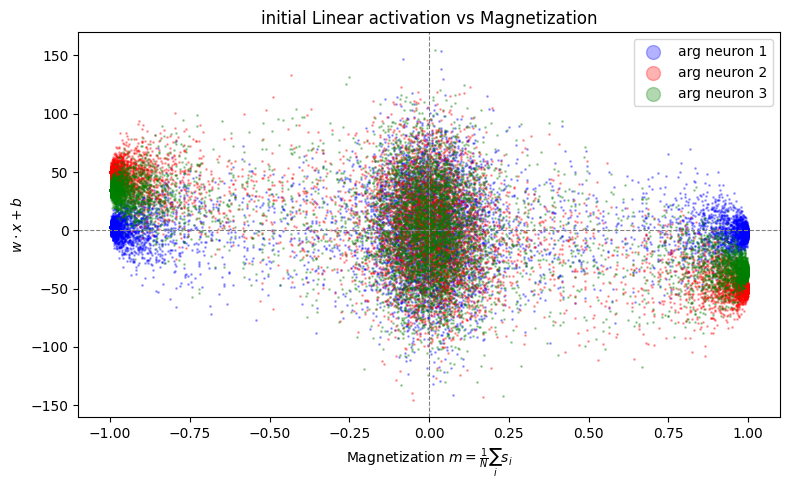

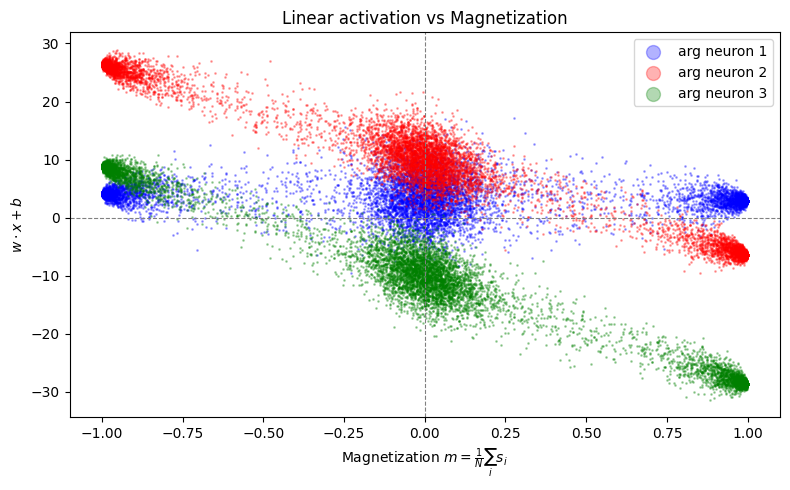

In [40]:
m = test_conf.mean(axis=1)
w, b = model3.layers[1].get_weights()
init_hidden_args = test_conf @ w_init + b_init
hidden_args = test_conf @ w + b
#print(hidden_args[:,0].shape)

plt.figure(figsize=(8, 5))
plt.scatter(m, init_hidden_args[:,0], s=1, alpha=0.3, color = 'b', label = 'arg neuron 1') #c=labels, cmap='coolwarm')
plt.scatter(m, init_hidden_args[:,1], s=1, alpha=0.3, color = 'r', label = 'arg neuron 2')   #c=labels, cmap='coolwarm')
plt.scatter(m, init_hidden_args[:,2], s=1, alpha=0.3, color = 'g', label = 'arg neuron 3')   #c=labels, cmap='coolwarm')
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel("Magnetization $m = \\frac{1}{N}\\sum_i s_i$")
plt.ylabel("$w \\cdot x + b$")
#plt.colorbar(label="Label (0=ordered, 1=disordered)")
plt.legend(markerscale=10)
plt.title("initial Linear activation vs Magnetization")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(m, hidden_args[:,0], s=1, alpha=0.3, color = 'b', label = 'arg neuron 1') #c=labels, cmap='coolwarm')
plt.scatter(m, hidden_args[:,1], s=1, alpha=0.3, color = 'r', label = 'arg neuron 2')   #c=labels, cmap='coolwarm')
plt.scatter(m, hidden_args[:,2], s=1, alpha=0.3, color = 'g', label = 'arg neuron 3')   #c=labels, cmap='coolwarm')
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel("Magnetization $m = \\frac{1}{N}\\sum_i s_i$")
plt.ylabel("$w \\cdot x + b$")
#plt.colorbar(label="Label (0=ordered, 1=disordered)")
plt.legend(markerscale=10)
plt.title("Linear activation vs Magnetization")
plt.tight_layout()
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 206us/step


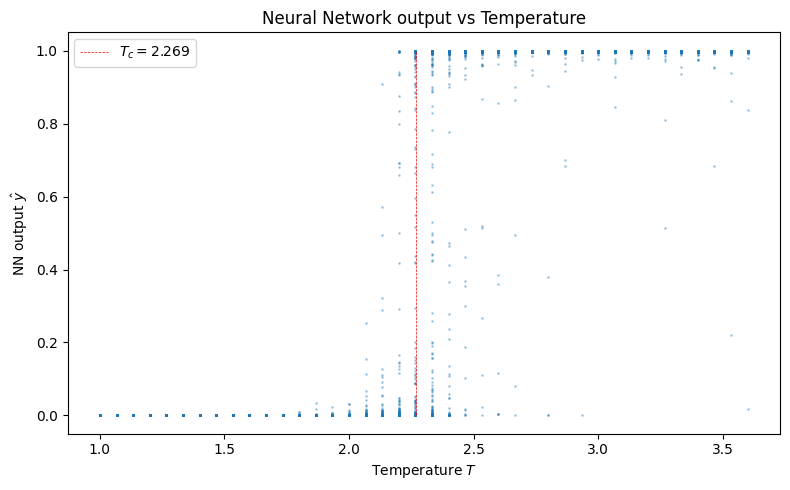

In [41]:
nn_predict = model3.predict(test_conf)

plt.figure(figsize=(8, 5))
plt.vlines(T_c,  ymin = 0, ymax = 1, color='red', linestyle='--', linewidth=0.5, label=f"$T_c = {T_c:.3f}$")
plt.scatter(test_T, nn_predict, s=1, alpha=0.3)
#plt.plot(T, nn_predict)
plt.xlabel("Temperature $T$")
plt.ylabel("NN output $\\hat{y}$")
plt.title("Neural Network output vs Temperature")
plt.legend()
plt.tight_layout()
plt.show()

### Plot magnetization

(10000,)
(10000,)


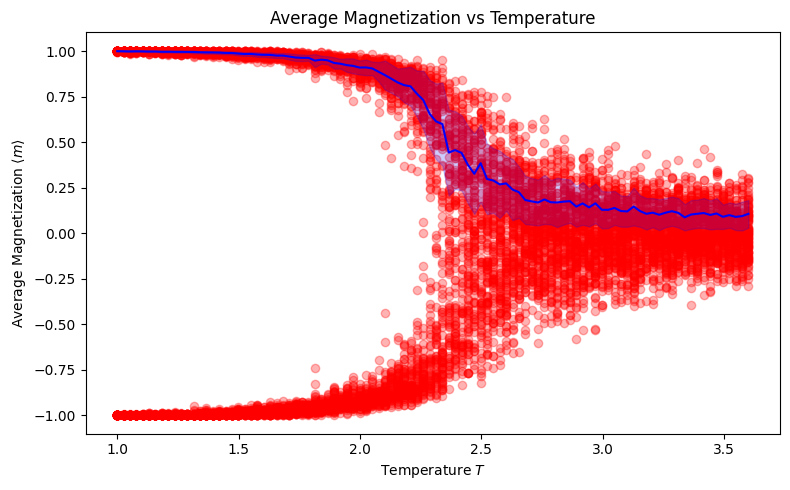

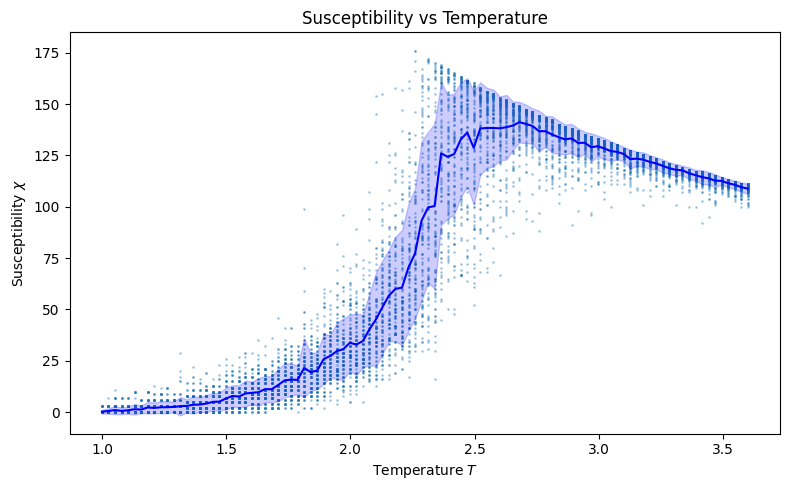

In [92]:
#data = np.load("../tri_data/L20_tri.npz")
data = np.load("../data_test/L20_ising.npz")
sp = data["spins"]
T = data["temperatures"]
N = sp.shape[1]
print(np.mean(sp**2, axis=1).shape)

          # total magnetization per sample: (n_temps, n_samples)
avg_magnetization = np.mean(sp, axis=1)  # (n_temps, n_samples)
print(avg_magnetization.shape)

chi = N*(np.mean(sp**2, axis=1) - np.mean(sp, axis=1)**2) // T

unique_T = np.unique(T)
mean_mag0 = np.array([np.abs(avg_magnetization[T == t]).mean() for t in unique_T])
sigma_mag0 = np.array([np.abs(avg_magnetization[T == t]).std() for t in unique_T]) 

mean_chi = np.array([chi[T == t].mean() for t in unique_T])
sigma_chi = np.array([chi[T == t].std() for t in unique_T]) 

plt.figure(figsize=(8, 5))
plt.scatter(T, avg_magnetization, alpha=0.3, color='r')
plt.plot(unique_T, mean_mag0, color='b')
plt.fill_between(unique_T, mean_mag0 - sigma_mag0, mean_mag0 + sigma_mag0, color='b', alpha=0.2)
plt.xlabel("Temperature $T$")
plt.ylabel("Average Magnetization $\\langle m \\rangle$")
plt.title("Average Magnetization vs Temperature")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(T, chi, s=1, alpha=0.3)
plt.plot(unique_T, mean_chi, color='b')
plt.fill_between(unique_T, mean_chi - sigma_chi, mean_chi + sigma_chi, color='b', alpha=0.2)
plt.xlabel("Temperature $T$")
plt.ylabel("Susceptibility $\\chi$")
plt.title("Susceptibility vs Temperature")
plt.tight_layout()
plt.show()

### NN with 3 nodes 2 outputs

In [42]:
def build_model(config_size, hidden_nodes):
    l2 = 1e-4  # regularization strength λ
    initializer = tf.keras.initializers.RandomNormal(mean=0.0, stddev=1.0)
    x = tf.keras.Input((config_size,))
    y = tf.keras.layers.Dense(hidden_nodes, activation='sigmoid', kernel_initializer=initializer, kernel_regularizer=tf.keras.regularizers.l2(l2))(x)
    z = tf.keras.layers.Dense(2, activation='sigmoid')(y)
    model = tf.keras.Model(inputs=x, outputs=z)
    model.compile(optimizer='adam', loss='binary_crossentropy')
    model.summary()
    return model

In [43]:
data = np.load("../data/L40_ising.npz")
"""split data into input and output"""
T = data["temperatures"]
T_c = 2 / np.log(1 + np.sqrt(2))        
labels = np.transpose(np.array([(T > T_c).astype(int), (T < T_c).astype(int)]))    #create labels from temperature
configs = data["spins"]

rng = np.random.default_rng(seed=42)
idx = np.arange(len(T))
rng.shuffle(idx)

# Apply the same permutation to all arrays
T = T[idx]
configs = configs[idx]
labels  = labels[idx, :]
print(labels.shape)

"""split into training, validation and test data"""
train_conf, val_conf, test_conf = np.split(configs, [80000, 90000])
train_label, val_label, test_label = np.split(labels, [80000, 90000], axis=0)
train_T, val_T, test_T = np.split(T, [80000, 90000])
#print(train_conf.shape)

model3_2 = build_model(1600, 3)

w_init, b_init = model3_2.layers[1].get_weights()

history = model3_2.fit(
    train_conf,
    train_label,
    validation_data = (val_conf, val_label),
    batch_size = 256,
    epochs = 50
)

(100000, 2)


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 3)              │         4,803 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 2)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,811 (18.79 KB)

 Trainable params: 4,811 (18.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 767us/step - loss: 1.1359 - val_loss: 1.0656
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 515us/step - loss: 1.0138 - val_loss: 0.9673
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 514us/step - loss: 0.9292 - val_loss: 0.8958
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 510us/step - loss: 0.8681 - val_loss: 0.8443
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 512us/step - loss: 0.8236 - val_loss: 0.8063
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 517us/step - loss: 0.7884 - val_loss: 0.7725
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 512us/step - loss: 0.7486 - val_loss: 0.7272
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 515us/step - loss: 0.6966 - val_loss: 0.6710
Epoch 9/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 513us/step - loss: 0.6398 - val_loss: 0.6178
Epoch 10/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 513us/step - loss: 0.5917 - val_loss: 0.5771
Epoch 11/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 509us/step - loss: 0.5565 - val_loss: 0.5453
Epoch 12/50
313/313 ━━━━━━━━━━

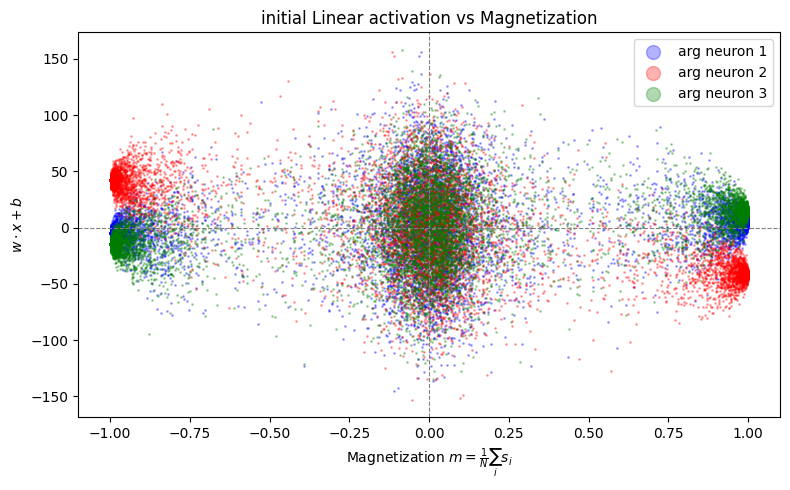

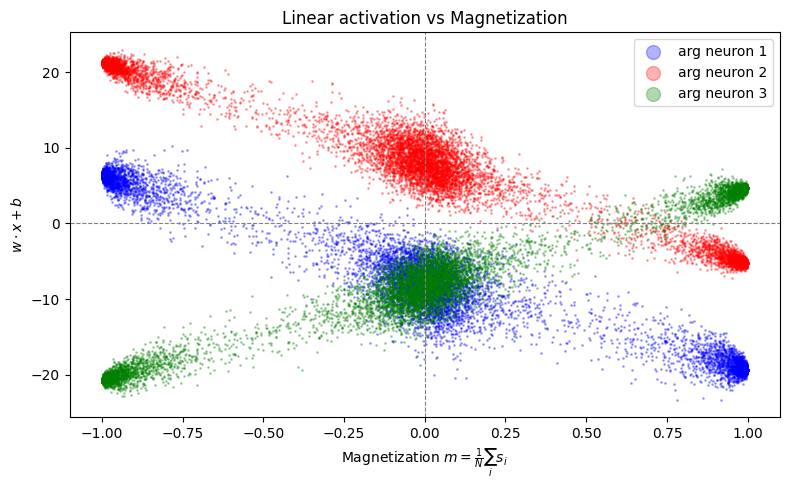

In [44]:
m = test_conf.mean(axis=1)
w, b = model3_2.layers[1].get_weights()
init_hidden_args = test_conf @ w_init + b_init
hidden_args = test_conf @ w + b
#print(hidden_args[:,0].shape)

plt.figure(figsize=(8, 5))
plt.scatter(m, init_hidden_args[:,0], s=1, alpha=0.3, color = 'b', label = 'arg neuron 1') #c=labels, cmap='coolwarm')
plt.scatter(m, init_hidden_args[:,1], s=1, alpha=0.3, color = 'r', label = 'arg neuron 2')   #c=labels, cmap='coolwarm')
plt.scatter(m, init_hidden_args[:,2], s=1, alpha=0.3, color = 'g', label = 'arg neuron 3')   #c=labels, cmap='coolwarm')
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel("Magnetization $m = \\frac{1}{N}\\sum_i s_i$")
plt.ylabel("$w \\cdot x + b$")
#plt.colorbar(label="Label (0=ordered, 1=disordered)")
plt.legend(markerscale=10)
plt.title("initial Linear activation vs Magnetization")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(m, hidden_args[:,0], s=1, alpha=0.3, color = 'b', label = 'arg neuron 1') #c=labels, cmap='coolwarm')
plt.scatter(m, hidden_args[:,1], s=1, alpha=0.3, color = 'r', label = 'arg neuron 2')   #c=labels, cmap='coolwarm')
plt.scatter(m, hidden_args[:,2], s=1, alpha=0.3, color = 'g', label = 'arg neuron 3')   #c=labels, cmap='coolwarm')
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel("Magnetization $m = \\frac{1}{N}\\sum_i s_i$")
plt.ylabel("$w \\cdot x + b$")
#plt.colorbar(label="Label (0=ordered, 1=disordered)")
plt.legend(markerscale=10)
plt.title("Linear activation vs Magnetization")
plt.tight_layout()
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 213us/step
(10000, 2)


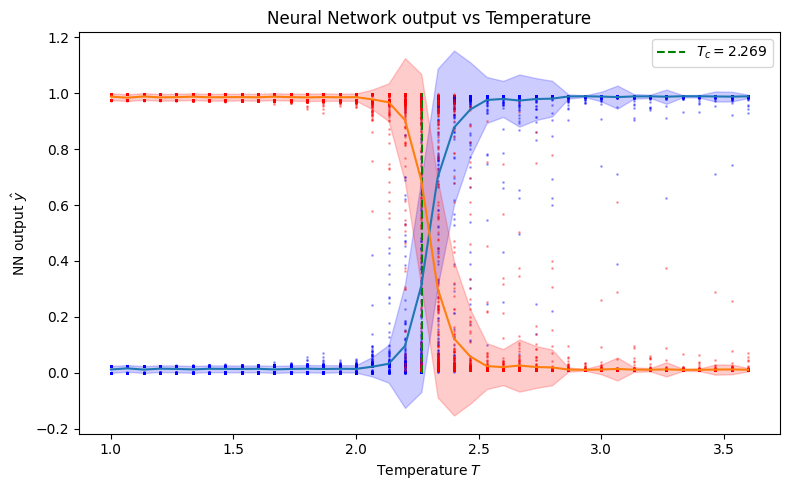

In [46]:
nn_predict = model3_2.predict(test_conf)
print(nn_predict.shape)

plt.figure(figsize=(8, 5))
plt.vlines(T_c,  ymin = 0, ymax = 1, color='g', linestyle='--', linewidth=1.5, label=f"$T_c = {T_c:.3f}$")
plt.scatter(test_T, nn_predict[:,0], s=1, alpha=0.3, color='b')
unique_T = np.unique(test_T)
mean_output0 = np.array([nn_predict[test_T == t, 0].mean() for t in unique_T])
sigma_output0 = np.array([nn_predict[test_T == t, 0].std() for t in unique_T])  
plt.plot(unique_T, mean_output0)
plt.fill_between(unique_T, mean_output0 - sigma_output0, mean_output0 + sigma_output0, color='b', alpha=0.2)
plt.scatter(test_T, nn_predict[:,1], s=1, alpha=0.3, color='r')
mean_output1 = np.array([nn_predict[test_T == t, 1].mean() for t in unique_T])
sigma_output1 = np.array([nn_predict[test_T == t, 1].std() for t in unique_T])
plt.plot(unique_T, mean_output1)
plt.fill_between(unique_T, mean_output1 - sigma_output1, mean_output1 + sigma_output1, color='r', alpha=0.2)
#plt.plot(T, nn_predict)
plt.xlabel("Temperature $T$")
plt.ylabel("NN output $\\hat{y}$")
plt.title("Neural Network output vs Temperature")
plt.legend()
plt.tight_layout()
plt.show()

### NN with 100 hidden nodes and 2 output nodes

In [ ]:
sizes = [10, 20, 30, 40, 60]
for L in sizes:
    data = np.load("../data/L30_ising.npz")
    """split data into input and output"""
    T = data["temperatures"]
    T_c = 2 / np.log(1 + np.sqrt(2))        
    labels = np.transpose(np.array([(T > T_c).astype(int), (T < T_c).astype(int)]))    #create labels from temperature
    configs = data["spins"]

    rng = np.random.default_rng(seed=42)
    idx = np.arange(len(T))
    rng.shuffle(idx)

    # Apply the same permutation to all arrays
    T = T[idx]
    configs = configs[idx]
    labels  = labels[idx, :]
    print(labels.shape)

    """split into training, validation and test data"""
    train_conf, val_conf, test_conf = np.split(configs, [80000, 90000])
    train_label, val_label, test_label = np.split(labels, [80000, 90000], axis=0)
    train_T, val_T, test_T = np.split(T, [80000, 90000])
    #print(train_conf.shape)

    model3_2 = build_model(900, 3)

    w_init, b_init = model3_2.layers[1].get_weights()

    history = model3_2.fit(
        train_conf,
        train_label,
        validation_data = (val_conf, val_label),
        batch_size = 256,
        epochs = 50
    )